

---




# MVP: *Machine Learning & Analytics*
**Autor:** Ana Luiza Abrao Roriz S. de Carvalho  

**Data:** 06/06/2026 - 28/06/2026

**Dataset:** Criação própria usando dataset Debêntures Anbima e campos Bloomberg

> **Importante:**
Dados extraidos usando terminal Bloomberg usando dados de debêntures brasileiras. Fonte dos dados: Anbima Data e Bloomberg
---



# 1. Escopo, objetivo e definição do problema

### 1.1 Motivação

Uma das premissas básicas do Wealth Management é sugerir produtos de acordo com o perfil de risco do cliente que está sendo atendido, tanto que um dos principais requisitos da CVM aos consultores é coletar, manter e sugerir produtos baseado no perfil de risco do cliente.

Há três perfis de cliente: **conservador, moderado e agressivo**. Estes perfis são calculados baseados no horizonte temporal do investidor, seu conhecimento sobre produtos financeiros, sua dispobibilidade de recursos e sua atitude em relação à flutuação no preço dos ativos. Cada perfil tem quantidades máximas permitidas de produtos mais arriscados, como ações ou derivativos.

Os títulos de renda fixa têm uma percepção do grande público como sendo produtos seguros, enquanto as ações são percebidas como investimentos de risco. Essa percepção vem pelo fato das ações apresentarem maior volatidade do que os títulos. Porém, eventos recentes no mercado de crédito privado brasileiro como os pedidos de recuperação judicial e extrajudicial de grandes empresas mostraram que eventos de crédito trazem riscos consideráveis aos ativos de renda fixa e que medir risco apenas por volatilidade não é suficiente.

A motivação deste trabalho é estudar a fundo uma base de dados de debêntures brasileiras. As debêntures são títulos de dívidas emitidos por empresas para captar recursos e financiar projetos. Elas podem ser compradas e vendidas em um mercado de balcão organizado na B3, a bolsa brasileira, acessível a fundos de investimenro e pessoas físicas operando através de corretoras.


### 1.2 Objetivo

O objetivo do trabalho é criar um mapa sistemático que organize as debêntures disponíveis no mercado em tiers de risco e buscar entender quais delas se encaixam nos perfis de suitability dos clientes (conservador, moderado e arrojado).

É importante dizer que este trabalho NÃO criará regras para classificar as debêntures, como por exemplo, dizer que aquelas com prazo curto são apropriadas a clientes conservadores. O objetivo é deixar os dados revelarem os agrupamentos naturais.

Devemos entender quais são os fatores de risco de uma debênture para entender a base de dados. **O risco de um título é dado por:**

*   **Duration:** prazo médio do título. Quanto mais longo é o prazo, mais esta dívida demorará a ser paga e sua sensibilidade a mudanças no juros é maior. A duration mede a sensibilidade do preço do título a variações na taxa de juros. Uma duration de 3 anos significa que para cada 1% de variação na taxa, o preço varia aproximadamente 3%.

*   **Spread:** prêmio de risco embutido na taxa. Mede quanto a mais a empresa paga de juros frente ao benchmark livre de risco (títulos do governo). Quanto maior o spread mais arriscado é o título.


*   **Volatilidade:** oscilação na taxa (logo também no preço) do título. Quanto maior a volatilidade mais arriscada é a debênture.



### 1.3 - Definição do Problema


O problema é de **aprendizado não supervisionado - clusterização**, pois temos features numéricas das debêntures e queremos descobrir grupos para elas. Não será dado nenhum rótulo aos dadosos e estes revelarão os agrupamentos naturais, com o número de clusters definido a partir de métricas de avaliação

Posteriormente os clusters serão interpretados e um perfil de suitability será atribuído a ele.

A área de aplicação é a de dados tabulares, pois teremos uma tabela com linhas, sendo cada linha uma debênture, e colunas, sendo as colunas suas variáveis numéricas ou categóricas.

Em particular, o campo da volatilidade das debêntures teve que ser calculado com base em séries de tempo. Foram coletados dados históricos da taxa de juros pagas pelas debêntures e a partir delas foi calculado o retorno diário e posteriormente o desvio padrao desses retornos em uma janela de um ano. A volatilidade é portanto representada pelo desvio padrao dos retornos das debêntures. Essa medida foi incorporada na base original através de um merge.

O valor deste trabalho para o wealth manager é ter parâmetros claros e testados para classificar os instrumentos antes de indicá-los aos clientes, sem incorrer em vieses ou preferências do consultor.

Uma extensão do trabalho seria construir um modelo classificador de aprendizado supervisionado o qual poderia classificar novas emissões de debêntures do mercado de acordo com os parâmetros gerados pela clusterização, sem precisar re-clusterizar todo o universo.

---

# 2. Reprodutibilidade e ambiente

O ambiente de execução é o Google Colab. Para os modelos e pré-processamento será usado o scikit-learn, com RobustScaler, Pipeline, ColumnTransformer, KMeans, AgglomerativeClustering e GaussianMixture. Para visualizações, matplotlib e seaborn.

O dataset foi extraído da Anbima e da Bloomberg e carregado em biblioteca pública GitHub.

Para reprodutibilidade foi escolhida a seed fixa 42: a reposta para a vida, o universo e tudo mais e por acaso também a idade da autora.

---


# 3. Dados: carga, entendimento e qualidade

Os dados das debêntures utilizados neste trabalho foram obtidos através de duas fontes: o Anbima Data, uma base pública da Anbima (Associação Brasileira das Entidades do Mercados Financeiros e de Capitais) em que é oferecida gratuitamente uma foto diária das debêntures negociadas no mercado brasileiro.

Estes dados foram complementados com outros obtidos através de uma licença de um terminal Bloomberg. A Bloomberg compila e trata os dados provenientes da B3 e outros provedores, como por exemplo os dados de rating das debêntures, que são calculadas pelas agências classificadoras de risco.

A Bloomberg entende o identificador único que a Anbima proporciona para cada ativo e pode-se completar a tabela de dados inicialmente obtida da Anbima com os da Bloomberg via conexão de API para a criação de uma base única.

A principal dificuldade encontrada nesta fase foi a ausência de dados de volatilidade na Bloomberg e na Anbima para as debêntures. Como esta é uma medida de risco de mercado crucial para a classificação dos ativos, teve-se que adicionar um passo adicional e calcular este dado separadamente através de uma outra base com séries de tempo, o que será explicado um pouco mais adiante.


### 3.1 Apresentação dos dados

In [34]:
#Inicialmente deve-se importar os pacotes para carregar, manipular e analisar as bases de dados
import os, random, time, sys, math
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score, confusion_matrix,
                             mean_absolute_error, mean_squared_error, r2_score,
                             silhouette_score)
from sklearn.cluster import AgglomerativeClustering
from sklearn.mixture import GaussianMixture

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print("Python:", sys.version.split()[0])
print("Seed global:", SEED)



Python: 3.12.13
Seed global: 42


In [35]:
#Agora vamos carregar a base de dados.

URL_CROSS = "https://raw.githubusercontent.com/analuizaar/MVP-machine_learning/refs/heads/main/02-base.csv"
df_base = pd.read_csv(URL_CROSS, encoding="utf-8-sig")

#É necessário fazer um pequeno ajuste adicionando espaços ao campo do ticker bloomberg para um merge que será feito posteriormente
df_base["ticker_bbg"] = df_base["ticker_bbg"].str.replace(r'\s+', ' ', regex=True).str.strip()
df_base.shape

(1209, 34)


A tabela dos dados foi organizada de modo a poder identificar claramente não só a debênture mas também suas características que possam ajudar a interpretar os clusters de forma adequada. Foram coletados dados de identificação do papel como seu ISIN, emissor, setor, indexador, garantias, tipo de cupom, data de emissão e vencimento.

Através dos comandos abaixo pode-se ver a data de referência dos dados, 24 de abril de 2026, as colunas de identificação das debêntures como seus códigos, emissores e tipo de remuneração, as taxas de mercado, a duration, outras características da emissão e por último a volatilidade calculada em um passo anterior.


In [36]:
df_base.head()

,data_referencia,codigo,ticker_bbg,emissor,tipo_remuneracao,remuneracao,data_vcto,tx_compra,tx_venda,tx_indicativa,...,PAYMENT_RANK,COLLAT_TYP,CALLABLE,DUR_ADJ_MID,BICS_LEVEL_1_SECTOR_NAME,CPN_TYP,ISSUE_DT,AMT_OUTSTANDING.1,INDUSTRY_SECTOR,INDUSTRY_GROUP
0,4/24/2026,AALM12,YU628929 Corp,AURA ALMAS MINERACAO S.A. (*),DI SPREAD,"DI + 1,6000%",02/10/2030,1.0205,0.6358,0.8329,...,Secured,SR SECURED,Y,NaN,Materials,FLOATING,02.out.2024,1.000000e+09,Basic Materials,Mining
1,4/24/2026,AEGPA9,YW120945 Corp,AEGEA SANEAMENTO E PARTICIPAÇÕES S/A (*),DI SPREAD,"DI + 2,7500%",25/06/2029,5.9153,4.1383,5.1194,...,Sr Unsecured,SR UNSECURED,Y,1.465577,Utilities,FLOATING,25.jun.2024,7.500000e+08,Utilities,Water
2,4/24/2026,AESLA7,YX229376 Corp,RGE SUL DISTRIBUIDORA DE ENERGIA S/A (*),IPCA SPREAD,"IPCA + 6,1409%",15/04/2034,7.5894,7.3369,7.4525,...,Sr Unsecured,SR UNSECURED,N,4.948845,Utilities,FIXED,15.abr.2024,5.568000e+08,Utilities,Electric
3,4/24/2026,AGEO15,YM016793 Corp,AGEO TERMINAIS E ARMAZENS GERAIS S/A (*),IPCA SPREAD,"IPCA + 7,6056%",15/06/2037,7.4626,7.1951,7.3284,...,Sr Unsecured,SR UNSECURED,N,6.254167,Industrials,FIXED,20.jun.2025,1.540000e+08,"Consumer, Cyclical",Storage/Warehousing
4,4/24/2026,ALGAC2,BU372442 Corp,ALGAR TELECOM S/A (*),IPCA SPREAD,"IPCA + 5,8806%",15/01/2032,8.4938,8.2838,8.4116,...,Sr Unsecured,SR UNSECURED,N,3.353957,Communications,FIXED,15.jan.2022,3.150000e+08,Communications,Telecommunications


Após a importação da base de dados das debêntures será feita a importação da base com a taxa dia a dia das debêntures para que seja calculado o retorno diário delas e o desvio padrão dos retornos, que será a medida de volatilidade. Para isso foi usado um terminal Bloomberg, no qual as debêntures têm um código identificador único. O campo utilizado foi o YLD YTM MID (yield to maturity mid), que representa a taxa média entre compra e venda da debênture. Foi feito o download dos dados dos últimos 252 dias úteis.

Adicionalmente como tratamento de dados, optou-se por excluir debêntures que tinham menos de 30 dias de taxa observada. Isso fez com que 24 ativos fossem excluídos por serem emissões sem o volume de dados suficiente para o cálculo de volatilidade e o universo de trabalho passou de 1209 debêntures para 1185.

O identificador único das debêntures na Bloomberg, conhecido como ticker, foi usado como chave comum para o merge entre as duas bases.


In [37]:
#Importaçao da base de dados com os dados históricos das taxas do último ano
URL_CROSS_a = "http://raw.githubusercontent.com/analuizaar/MVP-machine_learning/refs/heads/main/01-ytm_para_vol.csv"
df_ytm = pd.read_csv(URL_CROSS_a, encoding="utf-8-sig")
df_ytm.head()

,Date,BT345165 Corp,YU475355 Corp,YL621181 Corp,YM089223 Corp,ZF312539 Corp,YN099141 Corp,YJ732010 Corp,ZD095951 Corp,YQ565336 Corp,...,YK044689 Corp,YK405757 Corp,YT082506 Corp,BQ466513 Corp,YW562282 Corp,YW001885 Corp,BY440104 Corp,BS337988 Corp,DA259689 Corp,AL814958 Corp
0,2025-06-09 00:00:00,8.533423,0.681266,NaN,NaN,1.366225,NaN,NaN,0.958543,1.184569,...,NaN,NaN,6.361736,2.767634,3.480653,1.062346,NaN,1.523259,NaN,8.485933
1,2025-06-10 00:00:00,8.583077,0.679390,NaN,NaN,1.367603,NaN,NaN,0.959940,1.184036,...,NaN,NaN,6.525706,1.460512,1.561140,1.065753,NaN,1.511906,NaN,8.548504
2,2025-06-11 00:00:00,8.526978,0.677531,NaN,NaN,1.373347,NaN,NaN,0.958941,1.183515,...,NaN,NaN,6.580979,1.467575,1.310798,1.065994,NaN,1.451761,NaN,8.508856
3,2025-06-12 00:00:00,8.262425,0.663151,NaN,NaN,1.378057,NaN,NaN,0.959300,1.161935,...,NaN,NaN,6.559724,2.250833,2.745731,1.059680,NaN,1.463431,NaN,8.596416
4,2025-06-13 00:00:00,8.294510,0.667599,NaN,NaN,1.322054,NaN,NaN,0.956366,1.161479,...,NaN,NaN,6.553898,2.042998,2.729806,1.061948,NaN,1.469577,NaN,8.537449


É importante explicar que a volatilidade é calculada sobre o retorno das taxas, logo antes de aplicar o desvio padrão devemos calcular o retorno do título que é dado pela diferença da taxa de negociação de hoje contra a de ontem.

In [38]:
#calcular a volatilidade das debentures com pelo menos 30 dias de dados
# Mínimo de observações para calcular vol
MIN_OBS = 30

df_ytm_indexed = df_ytm.set_index("Date") #transforma a coluna date no inicio do dataframe, marcamos como identificador

# Conta dias válidos por ativo
n_obs = df_ytm_indexed.notna().sum()

# Calcula vol só para ativos com mínimo de observações
# Para calcular a vol primeiro fazemos o retorno (yt-yt-1) e calculamos o std do retorno
vol = df_ytm_indexed.diff().std().reset_index() #reser_index transforma o resultado num df de 2 colunas
vol.columns = ["ticker_bbg", "vol_ytm"]

# Zera vol de ativos com dados insuficientes
vol.loc[n_obs.values < MIN_OBS, "vol_ytm"] = None
# Remove espaços extras no ticker_bbg da base
df_base["ticker_bbg"] = df_base["ticker_bbg"].str.replace(r'\s+', ' ', regex=True).str.strip()


In [39]:
# Queremos descartar os ativos sem vol antes do merge
vol = vol[vol["vol_ytm"].notna()]

# Merge com a base, a chave é o ticker bloomberg
df = df_base.merge(vol, on="ticker_bbg", how="inner")

print(f"Ativos com vol calculada: {vol['vol_ytm'].notna().sum()}")
print(f"Ativos descartados por < {MIN_OBS} obs: {(n_obs < MIN_OBS).sum()}")
print(f"Vol nula após merge: {df['vol_ytm'].isna().sum()}")
df[["ticker_bbg", "z_spread", "duration", "vol_ytm"]].head()

Ativos com vol calculada: 1185
Ativos descartados por < 30 obs: 24
Vol nula após merge: 0


,ticker_bbg,z_spread,duration,vol_ytm
0,YU628929 Corp,0.8329,607.9284,0.239615
1,YW120945 Corp,5.1194,532.0685,0.475523
2,YX229376 Corp,1.0637,1433.9080,0.115404
3,YM016793 Corp,1.3663,1787.2755,0.083920
4,BU372442 Corp,1.9857,1020.3374,0.140262


Na base Anbima há uma coluna chamada "desvio padrão", porém não foram encontradas notas técnicas explicando se esse desvio padrão é equivalente à medida de volatilidade que acabou-se de calcular, ou qualquer explicação sobre as janelas de dados utilizadas. É interessante então plotar as duas séries juntas para entender se a vol_ytm calculada é similar ao desvio padrão da base Anbima.

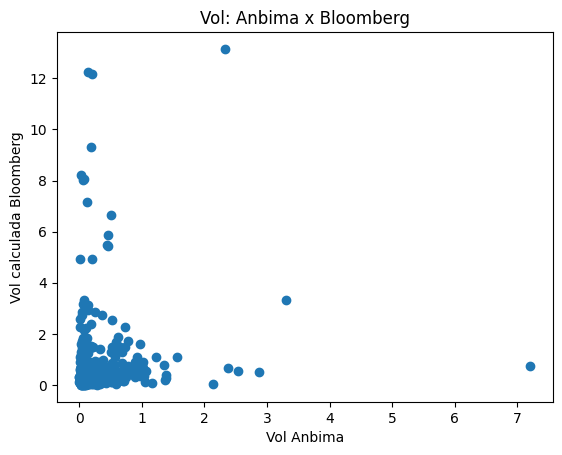

In [40]:
# Plotando o desvio padrao calculado na base Anbima (coluna desvio padrao) e a vol calculada pela Bloomberg (coluna vol_ytm)
# Anbima está em dias, converte para anos

plt.scatter(df["desp_pad"], df["vol_ytm"])
plt.title("Vol: Anbima x Bloomberg")
plt.xlabel("Vol Anbima")
plt.ylabel("Vol calculada Bloomberg")
plt.show()

O gráfico mostra que as medidas não são equivalentes, logo como não há clareza sobre como o desvio padrãoo da Anbima foi calculado, neste trabalho será usado o desvio padrão calculado sobre a taxa. A Anbima pode ter calculado o desvio padrão de outra variável.

Seguindo a análise dos dados, pode-se ver que há 35 colunas na base de dados completa após o calculo da volatilidade e 1185 debentures

In [41]:
# Mostra as dimensões do dataset
print(df.shape)
# Mostra as informações do dataset
print(df.info())


(1185, 35)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1185 entries, 0 to 1184
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   data_referencia           1185 non-null   object 
 1   codigo                    1185 non-null   object 
 2   ticker_bbg                1185 non-null   object 
 3   emissor                   1185 non-null   object 
 4   tipo_remuneracao          1185 non-null   object 
 5   remuneracao               1185 non-null   object 
 6   data_vcto                 1185 non-null   object 
 7   tx_compra                 1149 non-null   float64
 8   tx_venda                  1147 non-null   float64
 9   tx_indicativa             1185 non-null   float64
 10  pu_indicativo             1184 non-null   float64
 11  desp_pad                  1185 non-null   float64
 12  intervalo_indicativo_min  1185 non-null   float64
 13  intervalo_indicativo_ax   1185 non-null   float64
 1


### 3.2 EDA

Como a análise exploratória dos dados foi tratada de forma mais profunda em outros módulos deste curso, aqui será feita uma EDA resumida focada em ver as características gerais dos dados e em hipóteses sobre o comportamento das variáveis.

Algo importante a se fazer na análise inicial dos dados é entender as limitações dos valores ausentes.

Alguns campos são informativos que permitem identificar economicamente a classificação das debêntures em classes de risco diferentes e podem ser prescendidos, porém outros como duration e volatilidade são medidas de risco importante para a classificação dos títulos e seria contraproducente proceder sem eles na base.

In [42]:
# Mostra os valores ausentes por coluna
print("\nValores ausentes por coluna:")
print(df.isna().sum())


Valores ausentes por coluna:
data_referencia               0
codigo                        0
ticker_bbg                    0
emissor                       0
tipo_remuneracao              0
remuneracao                   0
data_vcto                     0
tx_compra                    36
tx_venda                     38
tx_indicativa                 0
pu_indicativo                 1
desp_pad                      0
intervalo_indicativo_min      0
intervalo_indicativo_ax       0
PU_pct_par                    1
duration                      1
ref_ntnb                    592
z_spread                      0
lei_12431                     0
vna                          12
pu_par                       12
RTG_SP_NATIONAL             853
RTG_FITCH_NATIONAL          742
AMT_OUTSTANDING               0
PAYMENT_RANK                  0
COLLAT_TYP                    0
CALLABLE                      0
DUR_ADJ_MID                  85
BICS_LEVEL_1_SECTOR_NAME      0
CPN_TYP                       0
ISSUE_DT  

Vendo os valores ausentes por coluna nota-se as colunas críticas com valores ausentes são: 24 linhas sem volatilidade (já havia sido visto anteriormente), 108 linhas sem duration calculada pela Bloomberg e 1 linha sem duration calculada pela Anbima. A escolha aqui será por remover esta debênture sem o duration. Não há problemas com as taxas de compra e venda faltantes, pois para o trabalho usaremos a **taxa indicativa** que é a taxa que a Anbima usa para a marcação do preço da debênture.

Outra variável com muitos valores fatantes é o rating, o qual será objeto de tratamento mais detalhado logo a frente.

Não há problema com os valores faltantes de "ref_ntnb", pois títulos que não são indexados ao IPCA não trabalham com essa referência. Para o trabalhoa referência de prêmio de risco usada será o "z_spread" calculado pela Anbima que já ajusta o prêmio da debênture ao título público correspondente a ela, de acordo com seu prazo e indexador.


In [43]:
# Remove a linha sem duration (única variável numérica do modelo com NaN)
df = df[df["duration"].notna()].reset_index(drop=True)
print(f"Shape após limpeza: {df.shape}")

Shape após limpeza: (1184, 35)




Como a duration nao deveria ser diferente entre as fontes, será feito um scatter plot para ver se há uma relação linear direta entre as duas medidas.

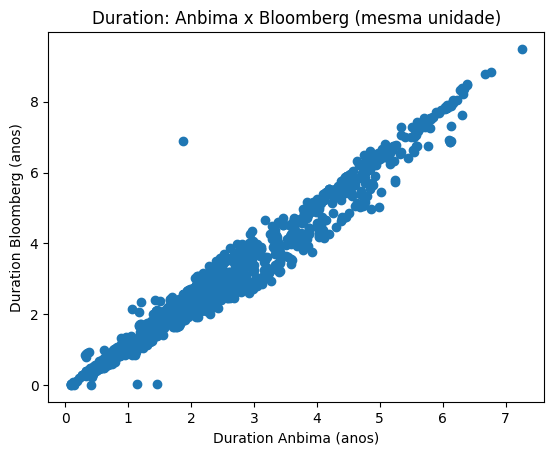

In [44]:
# Plotando a duration calculada na base Anbima (coluna duration) e a duration calculada pela Bloomberg (coluna dur adj mid)
# Anbima está em dias, converte para anos
df["duration_anos"] = df["duration"] / 365

plt.scatter(df["duration_anos"], df["DUR_ADJ_MID"])
plt.title("Duration: Anbima x Bloomberg (mesma unidade)")
plt.xlabel("Duration Anbima (anos)")
plt.ylabel("Duration Bloomberg (anos)")
plt.show()

Pode-se notar um papel que aparece como outlier na base. Ele tem cerca de 2 anos de duration pela Anbima e 7 anos de duration pela Bloomberg. Vale investigar para entender porque a discrepância

In [45]:
# Identifica o outlier
mask = (df["duration_anos"] < 2) & (df["DUR_ADJ_MID"] > 5)
df[mask][["ticker_bbg", "emissor", "duration_anos", "DUR_ADJ_MID", "data_vcto", "tipo_remuneracao"]]

,ticker_bbg,emissor,duration_anos,DUR_ADJ_MID,data_vcto,tipo_remuneracao
452,ZS540957 Corp,"B3 S/A - BRASIL, BOLSA, BALCÃO (*) (**)",1.867579,6.881555,05/11/2029,DI SPREAD


O outlier é uma debênture emitida pela B3, a bolsa brasileira. Ele remunera a CDI e tem data de vencimento em 2029, portanto é impossível que este papel tenha duration de 6 anos, pois lhe restam menos de 3 anos para o vencimento. A duration da Bloomberg está incorreta neste papel.
Com a exceção deste outlier mais gritante, pode-se ver que a duration medida pela Bloomberg e pela Anbima são muito similares, o que nos dá confiança de ignorar a coluna de duration da Bloomberg que tem mais valores faltantes e utilizar o cálculo da Anbima.

In [46]:
df = df.drop(columns=["DUR_ADJ_MID"])
print(df.shape)


(1184, 35)


Seguindo com a EDA:

Vamos olhar as variáveis que mostram as principais características de risco dos papeis, como explicado no início do trabalho: duration, z-spread e volatilidade.


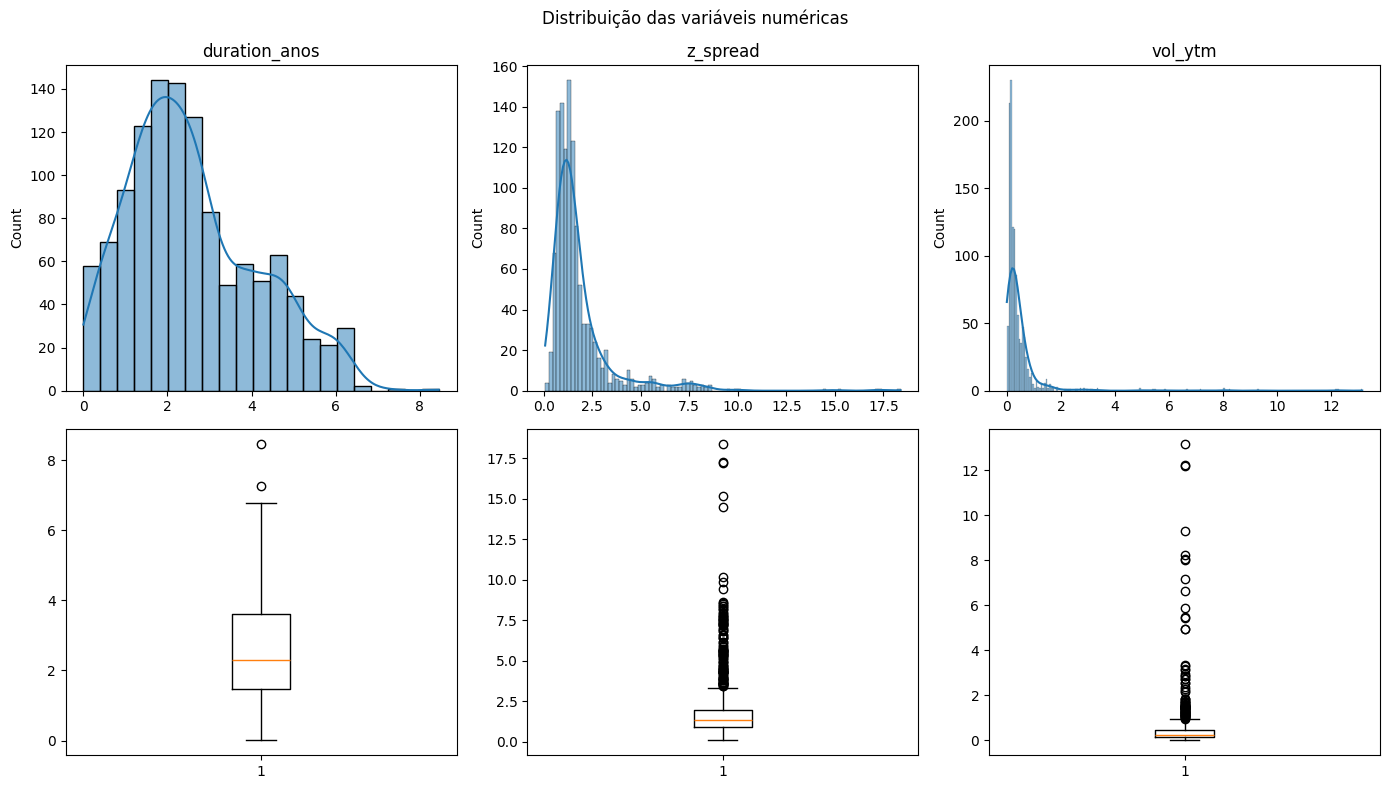

In [47]:
# Cria figura com 2 linhas e 3 colunas: linha de cima histograma, linha de baixo boxplot
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for i, col in enumerate(["duration_anos", "z_spread", "vol_ytm"]):

    # Linha de cima (axes[0]): histograma com KDE
    sns.histplot(df[col].dropna(), kde=True, ax=axes[0, i])
    axes[0, i].set_title(col)
    axes[0, i].set_xlabel("")

    # Linha de baixo (axes[1]): boxplot
    axes[1, i].boxplot(df[col].dropna())
    axes[1, i].set_title("")

plt.suptitle("Distribuição das variáveis numéricas")
plt.tight_layout()
plt.show()

Olhando para os histogramas e box plot temos:

**Duration_anos** — A maioria das debêntures tem entre 1 e 4 anos de duration, com mediana perto dos 2.5 anos. Há dois pontos acima de 7 que sao outliers, que sao emissoes mais longas.

**Z-spread** - A distribuiçao é extremamente assimétrica à direita, com caudas longas. A caixa do blox plot ficou extremamente comprimida e os papeis com spread mais alto aparecem quase todos como outliers, porém são emissoes economicamente válidas para a análise.

**Vol_ytm** - Outro caso de distribuiçao extremamente assimétrica à direita. A volatilidade dos papeis indexados a CDI é muito menor do que aqueles indexados a IPCA, o que comprime boa parte da volatilidade.

A EDA traz um questionamento sobre a separação dos papeis por indexador antes da clusterização. A estrutura dos papeis indexados por CDI é diferente daquela dos papeis indexados a IPCA. Os perfis de volatilidade e de spread também, o que seria um argumento a favor se separar a amostra. Porém isso reduziria o tamanho da amostra de dados.

A soluçao encontrada é rodar os modelos de clusterizaçao com a amostra completa e avaliar se o modelo por si só descobre essa diferença na estrutura dos papeis. Caso isso aconteça já será um resultado interessante de se ver, caso contrário, deve-se rodar a base separada em uma próxima iteração.

Uma inspeção dos papeis com taxa menor que 1 mostra que eles são aqueles que têm remuneraçao indexada a CDI, "DI DPREAD".

In [48]:
df[df["tx_indicativa"] < 1][["ticker_bbg", "emissor", "tipo_remuneracao", "tx_indicativa"]].head(10)

,ticker_bbg,emissor,tipo_remuneracao,tx_indicativa
0,YU628929 Corp,AURA ALMAS MINERACAO S.A. (*),DI SPREAD,0.8329
5,YT601885 Corp,CONCESSIONÁRIA DO SISTEMA ANHANGUERA-BANDEIRAN...,DI SPREAD,0.6813
12,YV462664 Corp,BR MALLS PARTICIPAÇÕES S/A (*),DI SPREAD,0.6399
19,YX783151 Corp,CIA DE ELETRICIDADE DO ESTADO DA BAHIA - COELB...,DI SPREAD,0.8752
23,ZB921576 Corp,CENTRAIS ELETRICAS DE RONDONIA S/A CERON,DI SPREAD,0.7024
26,ZB548775 Corp,COMPANHIA HIDRO ELETRICA DO SAO FRANCISCO - CH...,DI SPREAD,0.7391
27,YS161653 Corp,CHINA THREE GORGES BRASIL ENERGIA S.A. (*),DI SPREAD,0.6629
29,ZD801961 Corp,CEMIG DISTRIBUIÇÃO S/A (*),DI SPREAD,0.6397
30,YP503741 Corp,CEMIG DISTRIBUIÇÃO S/A (*),DI SPREAD,0.6820
35,YU539059 Corp,COPEL GERAÇÃO E TRANSMISSÃO S/A (*),DI SPREAD,0.9015


Uma debênture "CDI + 0.68%" é absolutamente normal no mercado brasileiro, especialmente para utilities como CEMIG, COELBA e COPEL que têm rating alto e pagam spread baixo justamente por serem emissores de baixo risco. O segundo pico no histograma em torno de 7-8% são provavelmente os papéis IPCA Spread, onde a taxa indica o spread sobre o IPCA, que naturalmente é maior que o spread sobre o CDI

Isso reforça a decisão de não usar tx_indicativa no modelo já que ela não é comparável entre papéis de indexadores diferentes. O z_spread é a variável correta porque já normaliza tudo para uma base comum.

Agora parte-se para analisar outras variáveis numéricas das debêntures e inclui-se as medidas de risco novamente mas em uma escala mais reduzida para uma melhor visualização dos dados.

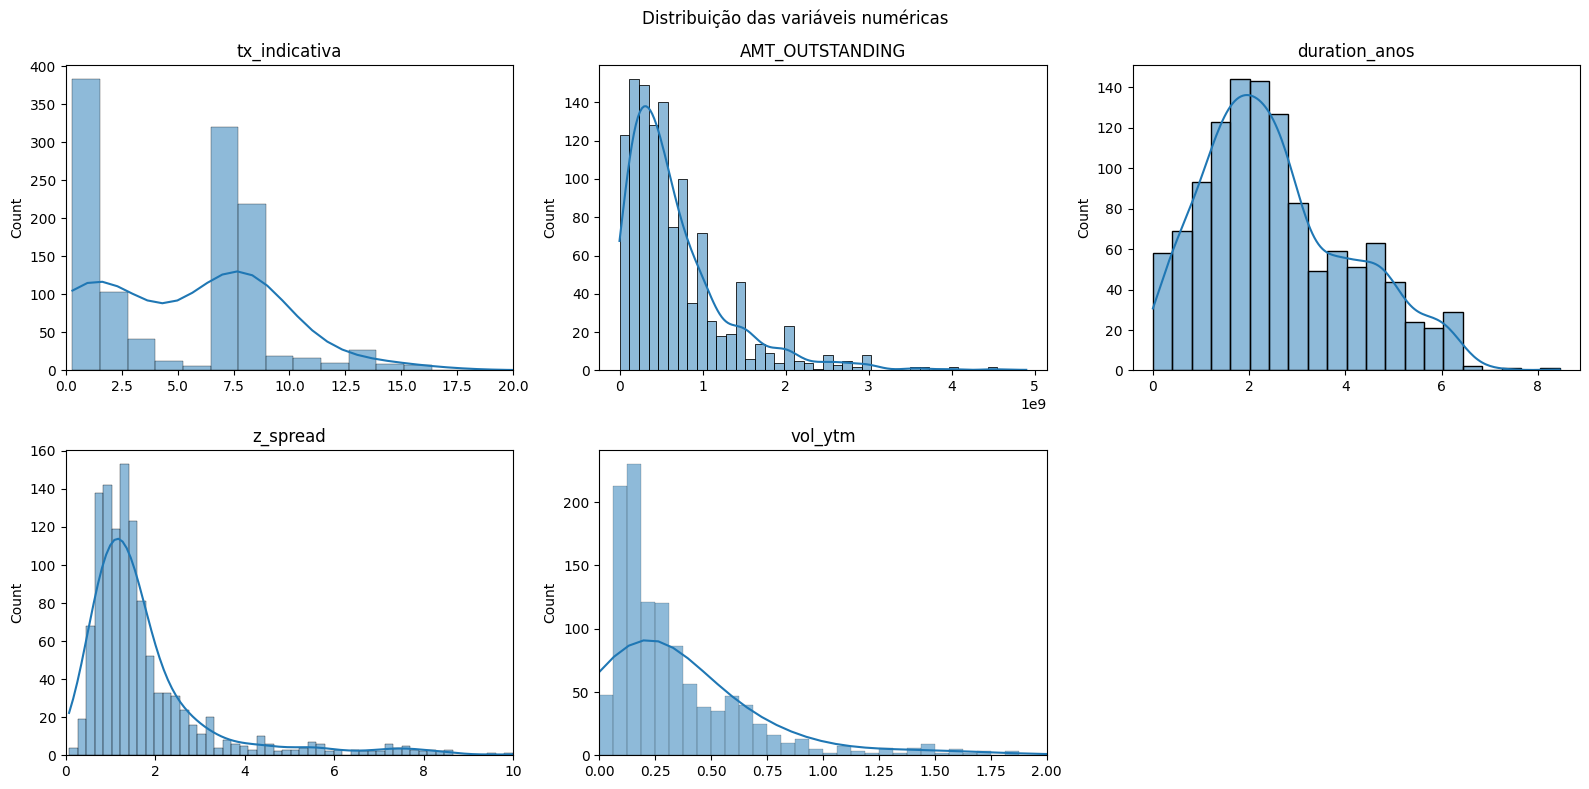

In [49]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

axes_flat = axes.flatten()

# Define limite do eixo x para cada variável (None = sem limite)
limites_x = {
    'tx_indicativa': (0, 20),
    'AMT_OUTSTANDING': None,
    'duration_anos': None,
    'z_spread': (0, 10),
    'vol_ytm': (0, 2)
}

for i, col in enumerate(['tx_indicativa', 'AMT_OUTSTANDING', 'duration_anos', 'z_spread', 'vol_ytm']):
    sns.histplot(df[col].dropna(), kde=True, ax=axes_flat[i])
    axes_flat[i].set_title(col)
    axes_flat[i].set_xlabel("")

    # Aplica limite se definido
    if limites_x[col]:
        axes_flat[i].set_xlim(limites_x[col])

axes_flat[5].set_visible(False)

plt.suptitle("Distribuição das variáveis numéricas")
plt.tight_layout()
plt.show()

Podemos ver que na **tx_indicativa** há algo de bi-modal na distribuição: os papeis indexados a CDI trabalham com taxa perto de 0, pois a maior parte da remuneraçao vem do próprio CDI. Na outra parte da distribuição vemos os papeis com taxas em torno de 7.5% que sao os papeis indexados a IPCA, já que 7.5% é o nível atual dos juros reais no Brasil.

Em **amt_outstanding** temos o tamanho da emissão da debênture. A distribuição é muito assimétrica, concentrada abaixo de R$1bi com uma cauda longa. A maioria das emissões é pequena/média, com poucos papéis muito grandes.

A **duration** tem uma distribuição reativamente bem comportada, ligeiramente assimétrica à direita. A maioria das emissões está entre 1 a 4 anos.

Após o zoom pode-ser ver que **z_spread** tem massa concentrada entre 0 e 3, que é o comportamento esperado para um papel do tipo investment grade brasileiro.

Na **vol_ytm** após o corte, pode-se ver uma concentração em valores baixos (0 a 0.5) reflete que a maioria das debêntures CDI+ tem taxa estável. A cauda até 2.0 são os papéis mais voláteis, aqueles indexados a IPCA.

Para o modelo pode-se ver que a interpretação dos dados que refletem as medidas de risco (vol e z-spread) ficou mais clara após o zoom sem os outliers. Portanto para o modelo é melhor usar o RobustScaler ao invés do StandardScaler para lidar com a assimetria das distribuições.

### A questao do rating na EDA
Foi visto anteriormente que há muitos ratings faltantes na base:

In [50]:
rating_cols = ["RTG_SP_NATIONAL", "RTG_FITCH_NATIONAL"]
print((df[rating_cols].isna().sum() / len(df) * 100).round(1).astype(str) + "%")

RTG_SP_NATIONAL       72.0%
RTG_FITCH_NATIONAL    62.7%
dtype: object


A primeira etapa, realizada nesta seção de EDA, consiste na limpeza e consolidação do rating. A base possui duas colunas de rating, uma da S&P e uma da Fitch, com formatos inconsistentes: prefixos como "br", sufixos como "(bra)" e atributos extras como "(P)", "+" e "-". A função limpar_rating padroniza esses valores para um formato limpo (ex: "AA+", "A-") e em seguida as duas agências são combinadas em uma única coluna, usando S&P como fonte primária e Fitch como secundária quando S&P não está disponível. Essa coluna consolidada é utilizada nas hipóteses exploratórias que relacionam rating com volatilidade e z-spread.

In [51]:
print("Ratings SP únicos:", sorted(df["RTG_SP_NATIONAL"].dropna().unique()))
print("Ratings Fitch únicos:", sorted(df["RTG_FITCH_NATIONAL"].dropna().unique()))

Ratings SP únicos: ['(P)brAA+', '(P)brAAA', 'NR', 'brA', 'brA+', 'brA+ *+', 'brA-', 'brAA', 'brAA+', 'brAA+ *-', 'brAA-', 'brAA- *-', 'brAAA', 'brBB+', 'brBBB+']
Ratings Fitch únicos: ['A(bra)', 'A+(bra)', 'A+(bra) *-', 'A-(bra)', 'AA(bra)', 'AA(bra) *-', 'AA+(bra)', 'AA-(bra)', 'AA-(bra) *-', 'AAA(bra)', 'AAA(bra) *-', 'BBB-(bra) *-', 'NR', 'WD']


In [52]:
import re

#limpeza dos prefixos, sufixos e extras

def limpar_rating(valor, agencia):
    if pd.isna(valor) or valor in ["NR", "WD"]:
        return None

    if agencia == "SP":
        # Remove prefixo br e sufixos como (P), *-, *+
        valor = re.sub(r'\(P\)', '', valor)  # remove (P)
        valor = re.sub(r'\s*\*[\+\-]', '', valor)  # remove *+ ou *-
        valor = re.sub(r'^br', '', valor)  # remove prefixo br

    elif agencia == "Fitch":
        # Remove sufixo (bra) e *-, *+
        valor = re.sub(r'\(bra\)', '', valor)  # remove (bra)
        valor = re.sub(r'\s*\*[\+\-]', '', valor)  # remove *+ ou *-

    return valor.strip()

# Aplica a limpeza via funçao criada
df["rtg_sp_clean"] = df["RTG_SP_NATIONAL"].apply(lambda x: limpar_rating(x, "SP"))
df["rtg_fitch_clean"] = df["RTG_FITCH_NATIONAL"].apply(lambda x: limpar_rating(x, "Fitch"))

# Confere os valores únicos após limpeza
print("SP limpo:", sorted(df["rtg_sp_clean"].dropna().unique()))
print("Fitch limpo:", sorted(df["rtg_fitch_clean"].dropna().unique()))

SP limpo: ['A', 'A+', 'A-', 'AA', 'AA+', 'AA-', 'AAA', 'BB+', 'BBB+']
Fitch limpo: ['A', 'A+', 'A-', 'AA', 'AA+', 'AA-', 'AAA', 'BBB-']


In [53]:
# Combina: usa SP como primário, Fitch como secundário
df["rating"] = df["rtg_sp_clean"].combine_first(df["rtg_fitch_clean"])

# Confere cobertura
print(f"Com rating: {df['rating'].notna().sum()}")
print(f"Sem rating: {df['rating'].isna().sum()}")
print(f"Valores únicos: {sorted(df['rating'].dropna().unique())}")

Com rating: 736
Sem rating: 448
Valores únicos: ['A', 'A+', 'A-', 'AA', 'AA+', 'AA-', 'AAA', 'BB+', 'BBB+', 'BBB-']


Pode-se ver que melhorou bastante a cobertura de rating com esta abordagem combinada.

In [54]:
total = len(df)
sp_cobertura = df["rtg_sp_clean"].notna().sum()
fitch_cobertura = df["rtg_fitch_clean"].notna().sum()
combinado_cobertura = df["rating"].notna().sum()

print(f"Total de debêntures: {total}")
print(f"Cobertura SP:        {sp_cobertura} ({sp_cobertura/total*100:.1f}%)")
print(f"Cobertura Fitch:     {fitch_cobertura} ({fitch_cobertura/total*100:.1f}%)")
print(f"Cobertura combinada: {combinado_cobertura} ({combinado_cobertura/total*100:.1f}%)")

Total de debêntures: 1184
Cobertura SP:        327 (27.6%)
Cobertura Fitch:     424 (35.8%)
Cobertura combinada: 736 (62.2%)



#### 3.2.1 Testando algumas hipóteses sobre o relacionamento entre as variáveis

Nessa etapa de EDA vale testar algumas das hipóteses mais comuns na classificação de risco das debêntures, como se a volatilidade está ligada a debêntures mais arriscadas. Para isso deve-se plotar a volatilidade contra o rating, duration e z-spread.

Espera-se que as debêntures mais voláteis tenham pior classificação de risco, ou seja, uma relação negativa entre vol e rating.

Para a duration, espera-se que as debêntures mais longas apresentem mais volatilidade em suas taxas.

E finalmente para o z-spread espera-se que quanto maior o zpread sobre os papeis soberanos maior a volatilidade.

Além disso podemos explorar estas mesmas relações entre as variáveis, como por exemplo plotando z-spread e rating e tentando entender se as debêntures com pior rating apresentam um spread maior com os títulos soberanos.

In [55]:
# Criando vetor das variáveis numéricas
numericas = ['tx_indicativa','AMT_OUTSTANDING', 'duration', 'z_spread','vol_ytm']
#quantitativas continuas fazer histograma e boxplot

# Criando vetor das variáveis categóricas
categoricas = ['INDUSTRY_SECTOR','tipo_remuneracao', 'COLLAT_TYP']

# Criando vetor das variáveis ordinais
ordinais = ['rating']


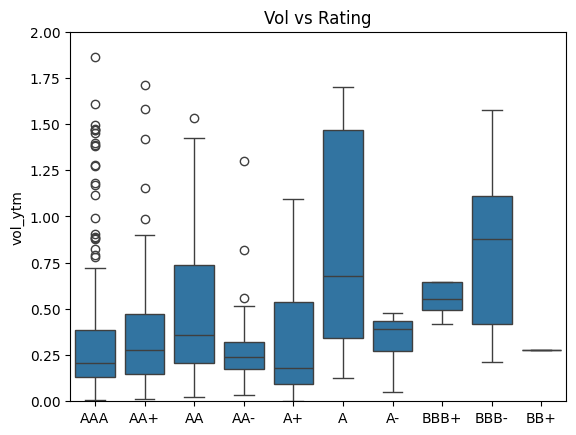

In [56]:
# Hipotese a ser testada: fazer um plot de rating vs vol. Ver se os maiores ratings tem a menor vol
# Hipótese 1: debêntures com pior rating têm maior volatilidade
ordem_rating = ["AAA", "AA+", "AA", "AA-", "A+", "A", "A-", "BBB+", "BBB-", "BB+"]

sns.boxplot(data=df, x="rating", y="vol_ytm", order=ordem_rating)
plt.title("Vol vs Rating")
plt.xlabel("")
plt.ylabel("vol_ytm")
plt.ylim(0, 2)
plt.show()

Pode-se ver pelo grafico:

**AAA e AA**- têm vol baixa e concentrada, o que é consistente com a hipótese.
**AA e A** - têm vol surpreendentemente alta, com caixas grandes, o que é inconsistente com a hipoótese. Isso pode estar ocorrendo caso os emissores destes ratings sejam de setores mais cíclicos ou voláteis.
**BBB- e BBB+** - têm vol elevada, o que é consistente com a hipótese.
**BB+**- tem só uma observação, então não é representativo para conclusões.


Pode-se concluir que rating sozinho não explica volatilidade. Ele é uma medida ligada a risco de crédito e nao risco de mercado, como o caso da volatilidade. Isso justifica usar outras features no modelo de clusterização.

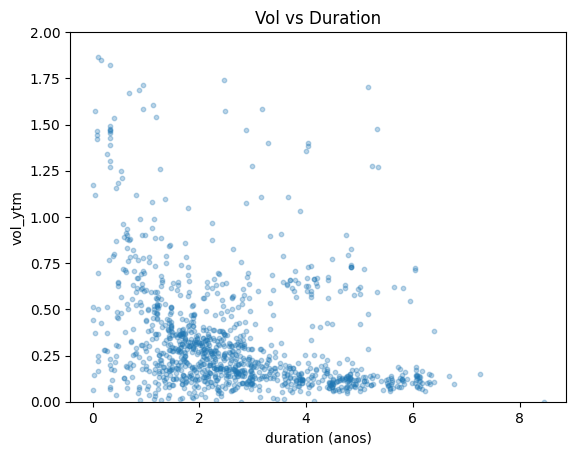

In [57]:
# Hipótese 2: debêntures com maior duration têm maior volatilidade
plt.scatter(df["duration_anos"], df["vol_ytm"], alpha=0.3, s=10)
plt.title("Vol vs Duration")
plt.xlabel("duration (anos)")
plt.ylabel("vol_ytm")
plt.ylim(0, 2)
plt.show()


Aqui temos outro resultado diferente do esperado anteriormente. Esperáva-se uma relação positiva entre as variáveis (mais duration, mais vol) mas o gráfico mostra uma relação negativa: papéis com duration curta têm vol alta e dispersa, enquanto papéis com duration longa têm vol baixa e concentrada.

Uma explicação para isso poderia vir do fato de papéis com duration muito curta (menos de 1 ano) podem caracterizar emissores em dificuldade, o que explicaria a vol alta.

Papéis longos (4-6 anos) tendem a ser de grandes utilities com rating AAA/AA, emissores estáveis com taxa marcada de forma consistente pela ANBIMA apresentando portanto uma vol mais baixa. Ou então estes papeis podem ser menos negociados e ter uma marcação mais estática da Anbima.

A duration no mercado de debêntures brasileiro parece ser fortemente correlacionada com o tipo de emissor. Em um país de juros historicamente altos e muitas incertezas macroeconômicas, apenas emissores sólidos conseguem captar a prazos mais longos.

A implicação para o modelo é que duration e vol não são independentes, elas têm correlação negativa como mostra a matriz abaixo.

In [58]:
corr_vars = df[['duration', 'z_spread', 'vol_ytm']].corr()
print(corr_vars.round(2))

          duration  z_spread  vol_ytm
duration      1.00     -0.01    -0.28
z_spread     -0.01      1.00     0.12
vol_ytm      -0.28      0.12     1.00


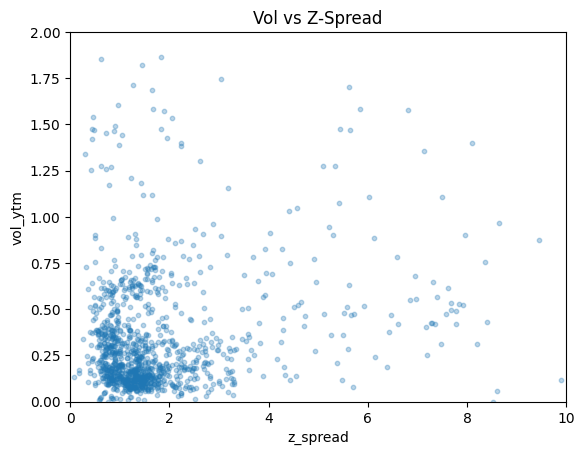

In [59]:
# Hipótese 3: debêntures com maior z_spread têm maior volatilidade
plt.scatter(df["z_spread"], df["vol_ytm"], alpha=0.3, s=10)
plt.title("Vol vs Z-Spread")
plt.xlabel("z_spread")
plt.ylabel("vol_ytm")
plt.xlim(0, 10)
plt.ylim(0, 2)
plt.show()

Pode-se ver no gráfico que papéis com z_spread baixo (0-2%) têm vol variada, de quase zero até 1.5%, com maior concentração entre 0 e 0.5%. Já papéis com z_spread alto (acima de 4%) têm comportamento muito disperso, sem tendência clara. Não há uma relação linear evidente entre as duas variáveis

Assim como aconteceu com o rating temos duas medidas de risco diferentes aqui que não necessariamente se correlacionam diretamente. O z_spread mede percepção de risco de crédito pelo mercado acima do benchmark soberano e a vol mede oscilação da taxa no tempo.

A questão da liquidez também pode ter alguma influência na descorrelação, já que papel pode ter spread alto mas taxa estável (emissor arriscado mas pouco negociado) e um papel pode ter spread baixo mas taxa volátil (emissor seguro mas com muita negociação diária).

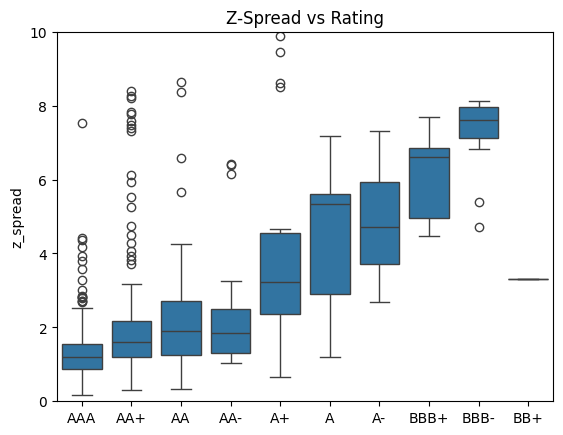

In [60]:
# Hipótese 4: debêntures com pior rating têm maior z_spread
ordem_rating = ["AAA", "AA+", "AA", "AA-", "A+", "A", "A-", "BBB+", "BBB-", "BB+"]

sns.boxplot(data=df, x="rating", y="z_spread", order=ordem_rating)
plt.title("Z-Spread vs Rating")
plt.xlabel("")
plt.ylabel("z_spread")
plt.ylim(0, 10)
plt.show()

Aqui finalmente temos uma relação conforme o esperado. O mercado precifica corretamente o risco de crédito, já que emissores com pior rating pagam mais spread sobre o governo.

É importante notar que aqui tem-se duas medidas de risco equivalentes. Ambas medem risco de crédito. Não há a mistura entre risco de crédito e risco de mercado das outras hipóteses.

O z_spread parece ser a melhor variável para capturar o risco de crédito no modelo. Ele é positivamente correlacionado com o rating e aparece para todas as variáveis da base.


### 3.3 Preparação dos Dados

#### 3.3.1 Feature Selection

Como foi visto anteriormente a base de dados possui 35 colunas, mas nem todas são necessárias para o objetivo deste trabalho. Para otimizar os cálculos e manter os dados organizados, deve-se separar quais são os dados que merecem ser mantidos na base. Para isso as variáveis relevantes serão separadas em 3 tipos: numéricas, categóricas e ordinais. Essa etapa de preparaçao dos dados é chamada de feature selection e consiste em manter na base apenas as variáveis consideradas relevantes.

**Variáveis numéricas:**

*   Taxa indicativa: taxa de juros média paga pela debênture, é um valor estatístico calculado ponderando as ofertas de compra e venda.
*   Volume: volume disponível da debênture no mercado (uma medida de liquidez do papel)
*   Duration: prazo médio da debênture, é uma das medidas de risco de mercado, mede a sensibilidade da taxa do papel a mudanças na curva de juros.
*   Z Spread: taxa em basis point que o papel paga acima dos títulos do governo (NTN-B, LFT ou NTN-F). É uma das medidas de risco de crédito, um prêmio que o mercado exige para carregar o papel do emissor privado ao invés do governo brasileiro. Como o campo Boomberg mede apenas o spread sobre as NTN-Bs, que são títulos corrigidos pela inflação, os títulos com outro indexador aparecem como valores faltantes. Para superar este problema será usado o calculo da Anbima de z-spread que é já calcula o spread do título privado com base no seu título público equivalente.
* Volatilidade: volatilidade em basis points da taxa, mede a variação observada da taxa em uma determinada janela de tempo, calculada sobre a série de tempo da bloomberg.


**Variáveis categóricas:**

*   Setor: setor da empresa emissora
*   Indexador: índice que corrige a dívida. Pode ser inflação, CDI ou pré fixado
*   Senioridade: direito de preferência a receber a garantia caso o emissor não consiga pagar a dívida;


**Variáveis ordinais**

*   Rating: nota para a emissão dada por uma agência classificadora de risco

OBS: Embora o rating seja uma variável categórica na origem ele tem uma ordem, na qual emissões menos arriscadas têm uma nota superior àquelas mais arriscadas, por isso deve ser classificada como variável ordinal.


In [61]:
# Variáveis que entram no modelo
features_modelo = ["duration_anos", "z_spread", "vol_ytm"]

# Variáveis interpretativas (não entram no modelo, usadas depois para interpretar clusters)
features_interpretativas = ["ticker_bbg", "emissor", "tipo_remuneracao",
                            "COLLAT_TYP", "BICS_LEVEL_1_SECTOR_NAME",
                            "tx_indicativa", "AMT_OUTSTANDING", "rating"]

# Dataset limpo com todas as colunas relevantes
df_modelo = df[features_modelo + features_interpretativas].copy()

print(df_modelo.shape)
df_modelo.head()

(1184, 11)


,duration_anos,z_spread,vol_ytm,ticker_bbg,emissor,tipo_remuneracao,COLLAT_TYP,BICS_LEVEL_1_SECTOR_NAME,tx_indicativa,AMT_OUTSTANDING,rating
0,1.665557,0.8329,0.239615,YU628929 Corp,AURA ALMAS MINERACAO S.A. (*),DI SPREAD,SR SECURED,Materials,0.8329,1.000000e+09,AA+
1,1.457722,5.1194,0.475523,YW120945 Corp,AEGEA SANEAMENTO E PARTICIPAÇÕES S/A (*),DI SPREAD,SR UNSECURED,Utilities,5.1194,7.500000e+08,A-
2,3.928515,1.0637,0.115404,YX229376 Corp,RGE SUL DISTRIBUIDORA DE ENERGIA S/A (*),IPCA SPREAD,SR UNSECURED,Utilities,7.4525,5.568000e+08,None
3,4.896645,1.3663,0.083920,YM016793 Corp,AGEO TERMINAIS E ARMAZENS GERAIS S/A (*),IPCA SPREAD,SR UNSECURED,Industrials,7.3284,1.540000e+08,None
4,2.795445,1.9857,0.140262,BU372442 Corp,ALGAR TELECOM S/A (*),IPCA SPREAD,SR UNSECURED,Communications,8.4116,3.150000e+08,AA


In [62]:
# Criar nova base apenas com as variáveis que importam
# Copiar o df antigo por segurança
df_copy = df.copy()


#### 3.3.2 Ordenação

O rating é uma variável categórica e ordenada. Deve-se covertê-lo para a escala numérica mantendo a sua ordem (por exemplo, AAA é melhor que C), logo o one hot encoding aqui não faz sentido aqui.  

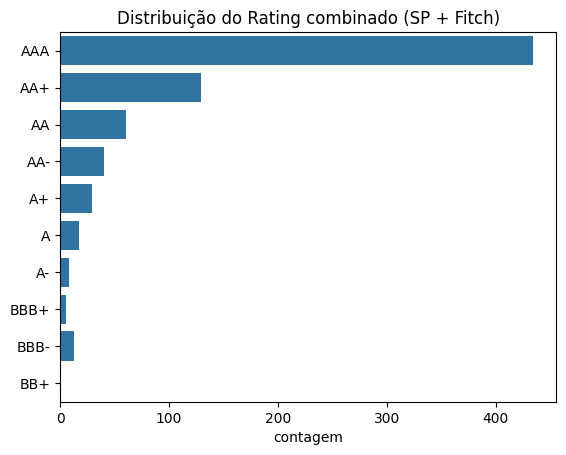

In [63]:
# Transformar o rating para variável numerica ordenada
# Mapa ordinal: AAA é o mais seguro (maior número), BB+ o mais arriscado (menor)
rating_map = {
    "AAA": 10, "AA+": 9, "AA": 8, "AA-": 7,
    "A+": 6,  "A": 5,   "A-": 4,
    "BBB+": 3, "BBB-": 2, "BB+": 1
}

df["rating_num"] = df["rating"].map(rating_map)

# Plot
sns.countplot(data=df, y="rating", order=rating_map.keys())
plt.title("Distribuição do Rating combinado (SP + Fitch)")
plt.xlabel("contagem")
plt.ylabel("")
plt.show()


## 4. Definição do target, variáveis e divisão dos dados

O problema é de **clusterização não supervisionada** como já foi mencionado anteriormente.

Não há um gabarito para o modelo seguir. Os dados serão agrupados por semelhança e esta será medida através de distâncias entre os pontos no modelo. K-means, Hierárquico e GMM são baseados em distâncias.

As features selecionadas para o modelo são duration, z-spread e volatilidade do YTM, por capturarem as dimensões de risco de mercado, crédito e incerteza de precificação dos títulos. Embora a clusterização seja não supervisionada, os dados são divididos em treino e teste seguindo a estrutura metodológica do curso, permitindo verificar se os agrupamentos encontrados se mantêm consistentes em dados não utilizados no ajuste do modelo.

In [64]:
# Selecione o tipo de problema: 'classificacao' | 'regressao' | 'clusterizacao' | 'serie_temporal'
PROBLEM_TYPE = "clusterizacao"  # TODO: ajuste

# Defina features e target conforme o problema
if PROBLEM_TYPE == "classificacao":
    target = "target_clf"
    features = ["duration_anos", "z_spread", "vol_ytm"]
elif PROBLEM_TYPE == "regressao":
    target = "target_reg"
    features = ["duration_anos", "z_spread", "vol_ytm"]
elif PROBLEM_TYPE == "clusterizacao":
    target = None
    features = ["duration_anos", "z_spread", "vol_ytm"]
elif PROBLEM_TYPE == "serie_temporal":
    target = "target_reg"  # Exemplo
    features = ["duration_anos", "z_spread", "vol_ytm"]
else:
    raise ValueError("PROBLEM_TYPE inválido.")

print("PROBLEM_TYPE:", PROBLEM_TYPE)
print("Target:", target)
print("N features:", len(features))

# Divisão dos dados
if PROBLEM_TYPE in ["classificacao", "regressao"]:
    X = df[features].copy()
    y = df[target].copy()
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=SEED, stratify=y if PROBLEM_TYPE=="classificacao" else None
    )
    print("Treino:", X_train.shape, "| Teste:", X_test.shape)
elif PROBLEM_TYPE == "clusterizacao":
    X = df[features].copy()
    # Sem target — você pode reservar um hold-out para avaliação externa se fizer sentido de negócio.
    X_train, X_test = train_test_split(X, test_size=0.2, random_state=SEED)
    print("Treino:", X_train.shape, "| Teste:", X_test.shape)
elif PROBLEM_TYPE == "serie_temporal":
    # Ordenar por tempo e criar cortes temporais (exemplo simples hold-out temporal)
    df_sorted = df.sort_values("timestamp")
    cutoff = int(len(df_sorted)*0.8)
    train, test = df_sorted.iloc[:cutoff], df_sorted.iloc[cutoff:]
    X_train, y_train = train.drop(columns=[target]), train[target]
    X_test, y_test   = test.drop(columns=[target]),  test[target]
    print("Treino:", X_train.shape, "| Teste:", X_test.shape)

PROBLEM_TYPE: clusterizacao
Target: None
N features: 3
Treino: (947, 3) | Teste: (237, 3)


O dataset conta com 1.184 títulos, divididos em 947 para treino (80%) e 237 para teste (20%), com 3 features (duration em anos, z spread e volatilidade das taxas).

----

## 5. Tratamento de dados e **Pipeline** de pré-processamento

Neste trabalho foi utilizado um Pipeline do scikit-learn para encadear as etapas de pré-processamento dos dados. O Pipeline garante que as transformações sejam sempre executadas na mesma ordem e nos mesmos dados, assegurando a reprodutibilidade do trabalho. No caso desta clusterização, o pipeline aplica SimpleImputer com estratégia de mediana e a padronização pelo RobustScaler, garantindo que qualquer dado novo passe pelas mesmas transformações antes de ser processado pelo modelo.

Para que as medidas de distâncias não sejam influenciadas pela unidade de medida de algum atributo do modelo é importante que elas possam ser comparáveis entre si.

Caso tenhamos duas features de um papel, como duration (que pode ir de 0 a 8) e volatilidade (que na maioria das vezes é um número menor que 0,5), o duration dominaria a medida entre os pontos.

A padronização coloca todas as variáveis na mesma escala, permitindo que o modelo calcule distâncias de forma justa entre elas. Será utilizado o RobustScaler ao invés do StandardScaler pois ele centraliza os dados na mediana e usa o intervalo interquartil como escala, sendo mais robusto a outliers e assimetria nas distribuições, como foi identificado na seção de EDA.

In [65]:
num_cols = [c for c in X_train.columns if str(X_train[c].dtype).startswith(("float","int"))]
cat_cols = [c for c in X_train.columns if c not in num_cols and c != "timestamp"]

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())  # RobustScaler no lugar do StandardScaler por causa da assimetria das distribuições
])

preprocess = ColumnTransformer(transformers=[
    ("num", numeric_pipe, num_cols)
])

X_train_processed = preprocess.fit_transform(X_train)
X_test_processed = preprocess.transform(X_test)

X_train_processed = pd.DataFrame(X_train_processed, columns=num_cols)
X_test_processed = pd.DataFrame(X_test_processed, columns=num_cols)

print("num_cols:", num_cols)
print("cat_cols:", cat_cols)
print(X_train_processed.describe().round(2))

num_cols: ['duration_anos', 'z_spread', 'vol_ytm']
cat_cols: []
       duration_anos  z_spread  vol_ytm
count         947.00    947.00   947.00
mean            0.13      0.48     0.71
std             0.72      1.74     3.00
min            -1.07     -1.26    -0.74
25%            -0.39     -0.42    -0.31
50%             0.00      0.00     0.00
75%             0.61      0.58     0.69
max             2.86     16.78    38.22


As variáveis categóricas não serão transformadas ou padronizadas pois terão uso na interpretação posterior do cluster, portanto a padronização foi aplicada apenas sobre as variáveis numéricas.

O rating, embora convertido para escala ordinal numérica, também não será incluído no modelo de clusterização devido à cobertura parcial de 62% da base. Será utilizado apenas como variável interpretativa para validar os clusters encontrados.

As variáveis de identificação como ticker, emissor e código não entram no modelo. Elas são mantidas no dataframe original para permitir a interpretação dos clusters após a modelagem.

Pode-se ver pela tabela acima que temos 947 debêntures na amostra de treino. As features tem média e desvio padrao próximos, com mediana (50%) igual a 0.00, mostrando que os dados passaram pelo robust scaler (notar que a média nao é 0 e sim a mediana, pois optou-se por nao usar a padronizaçao do standard scaler). Os máximos existem, mostrando que os outliers vistos na EDA foram mantidos pelo robust scaler sem distorcer a escala geral.

__________


## 6. Baseline e modelos candidatos


###6.1. Escolha do número de clusters

Antes de aplicar os modelos de clusterização, é necessário definir o número ideal de clusters K. Como o aprendizado não supervisionado não tem gabarito, não é possível simplesmente testar o modelo e medir o erro como em problemas supervisionados. Para isso serão utilizados dois métodos complementares: o Elbow Method, que avalia a inércia do modelo para diferentes valores de K e identifica o ponto de inflexão da curva onde adicionar mais clusters deixa de trazer ganho significativo, e o Silhouette Score, que mede o quão bem cada ponto está alocado no seu cluster comparado aos demais. A combinação dos dois métodos permite uma escolha mais robusta e justificada do K.

Há uma intuiçao sobre a divisao dos clusters em arrojado, moderado e conservador, mas nao será imposto K=3 para o modelo. A ideia é ver como os dados se comportam.

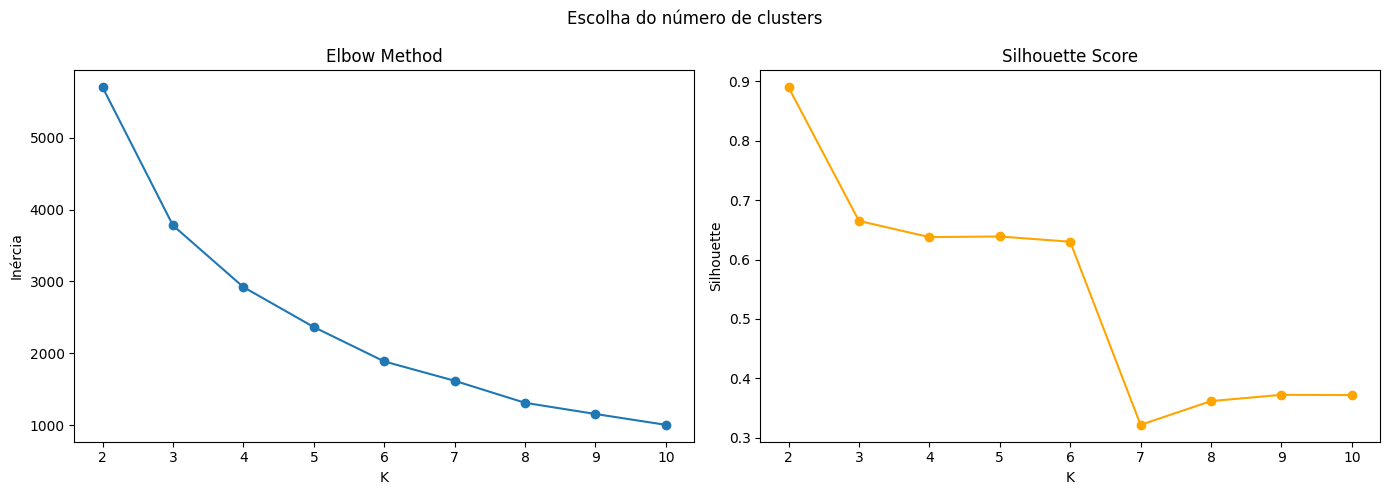

In [66]:

inertias = []
silhouettes = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = kmeans.fit_predict(X_train_processed)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_train_processed, labels))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, marker="o")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("K")
axes[0].set_ylabel("Inércia")

axes[1].plot(K_range, silhouettes, marker="o", color="orange")
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("K")
axes[1].set_ylabel("Silhouette")

plt.suptitle("Escolha do número de clusters")
plt.tight_layout()
plt.show()

K=2 é matematicamente o melhor pelo Silhouette, mas divide toda a base em apenas dois grupos, o que é pouco útil para o objetivo do trabalho que é criar tiers de risco para suitability (conservador, moderado, arrojado).

K=3 aparece como um bom meio termo entre os dois métodos. Ele tem bom score no Silhouette e há uma boa queda no Elbow de 2 para 3, a maior de todas inclusive. As quedas sucessivas sao de magnitude inferior. Ele faz sentido como ponto de partida, alinhado à intuição inicial de três tiers de risco, e será avaliado se os dados confirmam essa divisão

### 6.2. Algoritmos de agrupamento

De acordo com o material do curso temos: "O agrupamento (clusterização) é o processo que usamos para criar conjuntos de objetos e definir conjuntos (classes) de objetos similares." Para conseguir isso "é necessário definir um critério de similaridade que deverá ser usado durante o processo de criação de grupos". Os algoritmos de agrupamento servem para a definiçao deste critério.

O K means busca fixar k centróides , um para cada cluster. O Hierarchical produz uma árvore que demonstra as distâncias entre os grupos e subgrupos dentro do mesmo cluster e o GMM modela cada cluster como uma distribuição gaussiana, atribuindo a cada título uma probabilidade de pertencimento a cada grupo, permitindo capturar estruturas mais flexíveis e sobrepostas entre os perfis de risco.

O Silhouette Score é uma métrica utilizada para avaliar a qualidade dos agrupamentos gerados pelos algoritmos de clusterização. Para cada observação, o índice mede o quão similar ela é ao seu próprio cluster em comparação com os demais, variando de -1 a 1, onde valores próximos de 1 indicam clusters bem definidos e separados. Por ser uma métrica agnóstica ao algoritmo utilizado, o Silhouette Score permite comparar de forma justa os resultados do K-Means, do Hierarchical Clustering e do GMM, sendo adotado como critério de seleção do melhor método de segmentação para a base de títulos analisada.

Para garantir a robustez do KMeans foram utilizados dois parâmetros adicionais: o n_init=10, que instrui o algoritmo a realizar 10 inicializações aleatórias dos centróides e selecionar a solução com menor inércia, reduzindo o risco de convergência para um mínimo local, e o random_state=42 (definido no início do trabalho), que garante a reprodutibilidade dos resultados.

In [67]:
#K means é o baseline, o algoritmo mais simples dos 3 mencionados
baseline = KMeans(n_clusters=3, random_state=SEED, n_init=10)

candidates = {
    "hierarchical": AgglomerativeClustering(n_clusters=3),
    "gmm": GaussianMixture(n_components=3, random_state=SEED)
}

def evaluate_clustering(X, model):
    labels = model.fit_predict(X)
    return {"silhouette": round(silhouette_score(X, labels), 3)}

________________________


## 7. Avaliação final, análise de erros e limitações

No template do curso pede-se na sequencia a otimização de hiperparâmetros via validação cruzada, porém ela não se aplica diretamente à clusterização. A seleção do número de clusters k=3 foi realizada na seção 6.1 através do Elbow Method e do Silhouette Score, portanto agora segue-se para a interpretaçao dos clusters

In [75]:
# Scores no treino
results_train = {}
results_train["baseline"] = evaluate_clustering(X_train_processed, baseline)
for name, pipe in candidates.items():
    results_train[name] = evaluate_clustering(X_train_processed, pipe)

print("Scores no treino:")
display(pd.DataFrame(results_train).T)


results = {}

if PROBLEM_TYPE in ["classificacao", "regressao"]:
    # Baseline
    t0 = time.time()
    baseline.fit(X_train, y_train)
    t1 = time.time()
    if PROBLEM_TYPE == "classificacao":
        y_pred = baseline.predict(X_test)
        proba = baseline.predict_proba(X_test) if hasattr(baseline, "predict_proba") else None
        results["baseline"] = evaluate_classification(y_test, y_pred, proba)
    else:
        y_pred = baseline.predict(X_test)
        results["baseline"] = evaluate_regression(y_test, y_pred)
    results["baseline"]["train_time_s"] = round(t1 - t0, 3)

    # Candidatos
    for name, pipe in candidates.items():
        t0 = time.time()
        pipe.fit(X_train, y_train)
        t1 = time.time()
        if PROBLEM_TYPE == "classificacao":
            y_pred = pipe.predict(X_test)
            proba = pipe.predict_proba(X_test) if hasattr(pipe, "predict_proba") else None
            results[name] = evaluate_classification(y_test, y_pred, proba)
        else:
            y_pred = pipe.predict(X_test)
            results[name] = evaluate_regression(y_test, y_pred)
        results[name]["train_time_s"] = round(t1 - t0, 3)

elif PROBLEM_TYPE == "clusterizacao":
    # Baseline e candidatos (ex.: silhouette)
    # Observação: em um projeto real, evite refit em dados de teste fora de validação apropriada.
    results["baseline"] = evaluate_clustering(X_test, baseline)
    for name, pipe in candidates.items():
        results[name] = evaluate_clustering(X_test, pipe)

elif PROBLEM_TYPE == "serie_temporal":
    # TODO: implemente métricas específicas (ex.: MAE/MAPE/RMSE out-of-time)
    results["baseline_naive"] = {"MAE": None, "MAPE": None, "RMSE": None, "obs": "Implementar baseline temporal."}

print("Scores no teste:")
display(pd.DataFrame(results).T)


Scores no treino:


,silhouette
baseline,0.665
hierarchical,0.629
gmm,0.414


Scores no teste:


,silhouette
baseline,0.517
hierarchical,0.507
gmm,0.481


No treino, o K-Means obteve 0.665, o Hierarchical 0.629 e o GMM 0.414. No teste, os scores foram 0.517, 0.507 e 0.481 respectivamente. Os scores são menores no teste, o que é esperado, mas a ordem entre os algoritmos se manteve, indicando que os clusters encontrados são estáveis e generalizam para dados não vistos pelo modelo.

Depois de definir os clusters, deve-se conhecer as características de cada um deles. Agrupamos as variáveis por clusters e vemos as seguintes médias:

In [69]:
labels_kmeans = baseline.fit_predict(X_train_processed)
df_train = X_train.copy()
df_train["cluster"] = labels_kmeans

perfil = df_train.groupby("cluster")[["duration_anos", "z_spread", "vol_ytm"]].mean().round(3)
print(perfil)

print("\nTamanho dos clusters:")
print(df_train["cluster"].value_counts().sort_index())

         duration_anos  z_spread  vol_ytm
cluster                                  
0                2.607     1.442    0.327
1                0.225     1.751    7.537
2                2.624     6.705    0.818

Tamanho dos clusters:
cluster
0    864
1     12
2     71
Name: count, dtype: int64


**Cluster 0 (864 títulos)** — duration médio 2.6 anos, spread baixo (1.44), vol baixa. **Representa um perfil padrão das debentures brasileiras de boa qualidade.**

**Cluster 1 (12 títulos)** — duration curto de 0.22 anos, spread médio (1.75), vol altíssima.  **Perfil alta volatilidade (outliers de vol)**

**Cluster 2 (71 títulos)** — duration médio (2.62 anos), spread alto (6.7), vol baixa. **Perfil alto risco de crédito**

**Os clusters não seguem a classificação tradicional de risco conservador, moderado e agressivo. Eles sugerem uma leitura mais granular das debêntures: o cluster 0 agrupa títulos com perfil padrão de mercado, spread baixo e volatilidade controlada; o cluster 2 isola títulos com alto spread, capturando prêmio de risco de crédito; o cluster 1, o menor dos três, reúne títulos com volatilidade extremamente alta e duration curto, possivelmente papéis próximos do vencimento ou com eventos de crédito recentes, o que dificulta sua interpretação dentro de um perfil de risco convencional.**

### 7.1 Analisando os clusters com as variáveis interpretativas

Agora para concluir a análise econômica dos clusters vamos cruzá-los com as variáveis interpretativas que separamos para dar melhor interpretaçao às debêntures.

In [70]:
# Cruza clusters com variáveis interpretativas
df_train = X_train.copy()
df_train["cluster"] = labels_kmeans

for col in ["rating", "tipo_remuneracao", "BICS_LEVEL_1_SECTOR_NAME", "COLLAT_TYP"]:
    df_train[col] = df.loc[df_train.index, col].values

print(df_train.columns.tolist())

['duration_anos', 'z_spread', 'vol_ytm', 'cluster', 'rating', 'tipo_remuneracao', 'BICS_LEVEL_1_SECTOR_NAME', 'COLLAT_TYP']


In [71]:
for col in ["rating", "tipo_remuneracao", "BICS_LEVEL_1_SECTOR_NAME", "COLLAT_TYP"]:
    print(f"\n=== {col} por cluster ===")
    print(df_train.groupby("cluster")[col].value_counts().unstack(fill_value=0))


=== rating por cluster ===
rating    A  A+  A-  AA  AA+  AA-  AAA  BB+  BBB+  BBB-
cluster                                                
0         5  18   2  44   90   27  343    1     0     0
1         0   0   0   1    1    0    4    0     0     0
2        10   7   5   4   13    3    1    0     2     9

=== tipo_remuneracao por cluster ===
tipo_remuneracao  DI PERCENTUAL  DI SPREAD  IPCA SPREAD  PREFIXADO
cluster                                                           
0                             4        418          434          8
1                             2          7            3          0
2                             0         24           45          2

=== BICS_LEVEL_1_SECTOR_NAME por cluster ===
BICS_LEVEL_1_SECTOR_NAME  Communications  Consumer Discretionary  \
cluster                                                            
0                                     24                      83   
1                                      0                       0   
2

O cluster 0, que concentra a grande maioria dos títulos, é dominado por debêntures AAA e AA+ de empresas de Utilities (prestadoras de serviços de utilidade pública), majoritariamente SR UNSECURED, com remuneração equilibrada entre DI Spread e IPCA Spread, mostrando um perfil típico de infraestrutura com risco de crédito baixo. Corrobora a conclusão da sessão anterior de ser o perfil típico das debêntures brasileiras de boa qualidade.

O cluster 2 chama atenção por concentrar ratings mais baixos (BBB-, BB+) e maior presença de SR SECURED, além de setores como Communications e Materials. Isso sugere títulos com maior risco de crédito, onde a garantia real é necessária para viabilizar a emissão, coerente com o alto z-spread identificado anteriormente.

O cluster 1, com apenas 12 títulos, não apresenta um padrão setorial claro mas concentra a volatilidade extrema. São casos isolados que fogem ao comportamento típico do mercado de debêntures

### 7.2 Visualização dos Clusters (PCA 2D)

Como as features do modelo são três dimensões, a visualização direta dos clusters não é possível. O PCA (Principal Component Analysis) reduz essas três dimensões para duas componentes principais, preservando a maior parte da variância dos dados, e permite visualizar graficamente a separação entre os clusters identificados pelo K-Means.

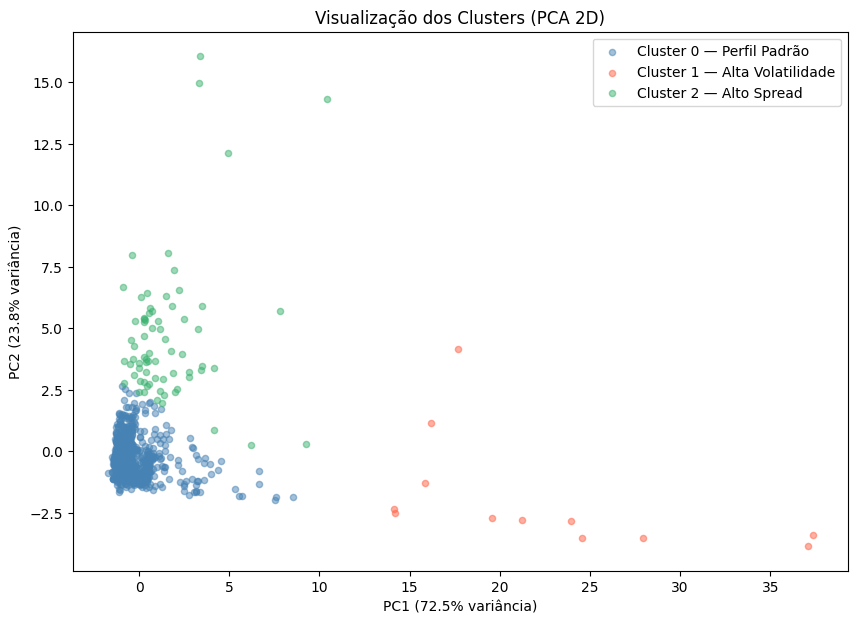

Variância explicada: 96.3%


In [72]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_train_processed)

plt.figure(figsize=(10, 7))
cores = {0: "steelblue", 1: "tomato", 2: "mediumseagreen"}
labels_cluster = {0: "Perfil Padrão", 1: "Alta Volatilidade", 2: "Alto Spread"}

for cluster in range(3):
    mask = df_train["cluster"] == cluster
    plt.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=cores[cluster],
        label=f"Cluster {cluster} — {labels_cluster[cluster]}",
        alpha=0.5, s=20
    )

plt.title("Visualização dos Clusters (PCA 2D)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variância)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variância)")
plt.legend()
plt.show()

print(f"Variância explicada: {pca.explained_variance_ratio_.sum()*100:.1f}%")

O PCA reduz as três features do modelo para duas dimensões que explicam 96.3% da variância dos dados, permitindo visualizar os clusters em um gráfico 2D. Cada eixo representa uma combinação das features originais encontrada pelo algoritmo: o eixo horizontal (PC1) captura principalmente a variação de volatilidade, enquanto o eixo vertical (PC2) captura principalmente a variação de z-spread. O cluster 0 se concentra próximo à origem, refletindo seu perfil padrão de spread e volatilidade baixos. O cluster 1 se estende para a direita, onde a volatilidade é alta. O cluster 2 se dispersa para cima, onde o spread é alto. A separação visual entre os três grupos confirma que os clusters são geometricamente distintos.

### 7.3. Análise de erros

Por se tratar de um problema de aprendizado não supervisionado, não há gabarito para comparar as previsões do modelo, o que inviabiliza o uso de métricas tradicionais como a matriz de confusão. A análise de qualidade foi realizada através do Silhouette Score, que indicou boa separação para os clusters 0 e 2 e separação mais fraca para o cluster 1, composto por títulos com comportamento atípico de volatilidade. A visualização pelo PCA confirmou que os três grupos são geometricamente distintos, com o cluster 1 se isolando no eixo de maior variância. Os títulos na fronteira entre os clusters 0 e 2 representam os casos mais ambíguos do modelo, onde o spread ainda não é suficientemente alto para caracterizar risco de crédito elevado, mas já se distancia do perfil padrão.

In [73]:
from sklearn.metrics import silhouette_samples

# Calcula silhouette individual de cada título
silhouette_vals = silhouette_samples(X_train_processed, df_train["cluster"])
df_train["silhouette"] = silhouette_vals

# Títulos na fronteira: silhouette baixo (entre -0.1 e 0.1)
fronteira = df_train[df_train["silhouette"].between(-0.1, 0.1)].copy()
fronteira["ticker_bbg"] = df.loc[fronteira.index, "ticker_bbg"].values
fronteira["emissor"] = df.loc[fronteira.index, "emissor"].values

print(f"Títulos na fronteira: {len(fronteira)}")
print(fronteira[["ticker_bbg", "emissor", "rating", "cluster", "silhouette",
                  "duration_anos", "z_spread", "vol_ytm"]].sort_values("silhouette"))

Títulos na fronteira: 12
        ticker_bbg                                            emissor rating  \
537  YL356101 Corp                             ORIGEM ENERGIA S.A (*)   None   
489  YQ483680 Corp                      ENGIE BRASIL ENERGIA S.A. (*)   None   
137  ZH228292 Corp           AEGEA SANEAMENTO E PARTICIPAÇÕES S/A (*)     A-   
826  BU678740 Corp                            USINA SANTA ADÉLIA S.A.    AA-   
577  BR508544 Corp  AGRO INDUSTRIAS DO VALE DO SAO FRANCISCO SA - ...      A   
705  YK600756 Corp            BIOENERGETICA VALE DO PARACATU S/A. (*)   None   
317  YQ208159 Corp  COMPANHIA ESTADUAL DE GERACAO DE ENERGIA ELETR...   BBB-   
948  BX581096 Corp                       MOVIDA PARTICIPACOES S/A (*)   None   
795  YJ304319 Corp                                  QUALICORP S/A (*)   None   
727  ZD767942 Corp           COMPANHIA PIRATININGA DE FORÇA E LUZ (*)    AAA   
437  BR960250 Corp           AEGEA SANEAMENTO E PARTICIPAÇÕES S/A (*)     A+   
675  BO691429 C

Os títulos na fronteira são emissores em situação de estresse de crédito incipiente, onde o mercado já precifica um prêmio no spread mas a volatilidade ainda não confirma a incerteza. O caso da Aegea Saneamento ilustra bem esse padrão: a empresa atrasou a divulgação dos demonstrativos contábeis no primeiro trimestre, gerando desconfiança no mercado, e seus títulos aparecem com silhouette negativo no cluster 2, indicando que o modelo também hesitou na classificação.

### 7.4. Conclusao final

O trabalho propôs uma segmentação de debêntures brasileiras com base em características de risco de mercado e crédito. Utilizando duration, z-spread e volatilidade do YTM, foi possível identificar três grupos distintos de títulos: um perfil padrão, que concentrou a grande maioria das debêntures, duration médio e risco de crédito baixo, um grupo com alto spread de crédito e duration médio e um grupo com volatilidade extrema.

A análise dos grupos confirmou coerência com a realidade do mercado. O perfil padrão reuniu debêntures de alta qualidade de crédito do setor de Utilities, enquanto o grupo de alto spread concentrou emissores com ratings mais baixos e maior necessidade de garantias. A análise dos títulos mais difíceis de classificar identificou casos de emissores em situação de estresse, como a Aegea Saneamento, cujos títulos já refletiam desconfiança do mercado no spread antes que outros sinais se tornassem evidentes.

O trabalho tem limitações importantes. A base cobre um único dia, o que impede avaliar se os grupos se mantêm estáveis ao longo do tempo. As variáveis escolhidas não capturam todas as dimensões de risco de uma debênture, como liquidez e estrutura de pagamentos. Por fim, a concentração de mais de 90% dos títulos em um único grupo sugere que a base é bastante homogênea, e que análises futuras poderiam explorar subdivisões dentro desse grupo dominante.

É importante notar que os clusters não reproduzem a classificação tradicional do investidor pela CVM em conservador, moderado e arrojado. A segmentação encontrada é mais específica ao mercado de debêntures: o risco de crédito foi a dimensão que mais separou os grupos, distinguindo títulos para investidores dispostos a correr risco de crédito em troca de um spread maior daqueles que preferem um perfil mais previsível. O terceiro grupo, de volatilidade extrema, representa um perfil essencialmente especulativo, com comportamento atípico que foge ao padrão do mercado